In [1]:
from pathlib import Path
import xarray as xr
import torch
import torch.nn.functional
from climanet.st_encoder_decoder import SpatioTemporalModel
from climanet.utils import pred_to_numpy, set_seed, configure_compute_resources, plot_results, plot_histograms
from climanet.train import train_monthly_model
from climanet.predict import predict_monthly_var
from climanet import STDataset

from torch.utils.data import random_split
from tbparse import SummaryReader
import matplotlib.pyplot as plt

import time

## Read data

In [2]:
# without diurnal cycle
data_folder = Path("./eso4clima/watervapor")
run_dir = "./runs_hourly_watervapor"
var_name = "prw"

file_names = [data_folder / f"202001_hr_ERA5_masked_{var_name}.nc", data_folder / f"202002_hr_ERA5_masked_{var_name}.nc"]
hourly_data = xr.open_mfdataset(file_names, chunks={"time": 1, "latitude": 80, "longitude": 80}).sortby("lat")

file_names = [data_folder / f"202001_mon_ERA5_full_{var_name}.nc", data_folder / f"202002_mon_ERA5_full_{var_name}.nc"]
monthly_data = xr.open_mfdataset(file_names, chunks={"time": 1, "latitude": 80, "longitude": 80}).sortby("lat")

file_name = data_folder / "era5_lsm_bool.nc"  # downloded from era5 and regridded using the function `regrid_to_boundary_centered_grid`
lsm_mask = xr.open_dataset(file_name)
# lsm_mask = lsm_mask.rename({'latitude': 'lat', 'longitude': 'lon'})

# Down sample mask to match the resolution of the monthly data
lsm_mask = lsm_mask.coarsen(lat=2, lon=2, boundary='trim').mean()
# Set <0.5 to 0 and >=0.5 to 1
lsm_mask = (lsm_mask >= 0.5).astype(bool)

In [20]:
monthly_data

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 2, bnds: 2, lat: 320, lon: 720)
Coordinates:
  * time       (time) datetime64[ns] 16B 2020-01-16T11:30:00 2020-02-15T11:30:00
  * lat        (lat) float32 1kB -79.75 -79.25 -78.75 ... 78.75 79.25 79.75
  * lon        (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
    prw        (time, lat, lon) float32 2MB dask.array<chunksize=(1, 320, 720), meta=np.ndarray>
Attributes:
    CDI:                     Climate Data Interface version 2.2.4 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Jul 06 10:02:21 2026: cdo monmean /work/bd08...
    regrid_method:           bilinear
    frequency:               mon
    CDO:                     Climate Data Operators version 2.2.2 (https://mp...

## Subset data (for fast example)

In [3]:
# coordinates of subset
lon_subset = slice(-50, 50) 
lat_subset = slice(-30, 10)

hourly_subset = hourly_data.sel(lon=lon_subset, lat=lat_subset).compute()
monthly_subset = monthly_data.sel(lon=lon_subset, lat=lat_subset).compute()
lsm_subset = lsm_mask.sel(lon=lon_subset, lat=lat_subset)  # True=Land

print(hourly_subset[var_name].shape, monthly_subset[var_name].shape)  # (time, lat, lon)

(1440, 80, 200) (2, 80, 200)


In [4]:
# calculate residuals as target
hourly_subset_averaged = hourly_subset.resample(time="MS").mean(skipna=True)
hourly_subset_averaged["time"] = monthly_subset["time"]

# Residuals
monthly_subset_res = monthly_subset - hourly_subset_averaged

## Train the model

In [5]:
# create the model (small)
set_seed()

patch_size = (1, 4, 4)
model = SpatioTemporalModel(patch_size=patch_size, overlap=2, embed_dim=64, dropout=0.2, hidden=64)

In [6]:
# create dataset
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset = STDataset(
    input_da=hourly_subset[var_name],
    monthly_da=monthly_subset_res[var_name],
    land_mask=lsm_subset["lsm"],
    patch_size=(1, *spatial_patch_size),  # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    is_hourly=True,
    
)
print(len(dataset))

Patch grid (m x i x j): 2 x 6 x 21 = 252 patches
Overlap: 32 pixels (height), 32 pixels (width)
252


In [7]:
# create train test data
generator = torch.Generator().manual_seed(42)
train_size = int(0.6 * len(dataset))
validation_size = int(0.3 * len(dataset))
test_size = len(dataset) - train_size - validation_size
train_dataset, validation_dataset, test_dataset = random_split(dataset, [train_size, validation_size, test_size], generator=generator)
print(len(train_dataset), len(validation_dataset), len(test_dataset))

151 75 26


### Start training loop

In [8]:
# Device and resources
compute_threads = 4
dataloader_num_workers = 2
device = "cpu" # use cuda if GPU is available
model = configure_compute_resources(model, device=device, compute_threads=compute_threads, dataloader_num_workers=dataloader_num_workers)

In [9]:
start = time.time()
# verbose is True
batch_size = 10
trained_model = train_monthly_model(
    model, train_dataset, validation_dataset=validation_dataset, batch_size=batch_size, num_epoch=100, accumulation_steps=20, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

total_time = (time.time() - start) / 60.0
print(f"{total_time:.2f}")

Epoch 0: gap between train and val loss: -0.291461
Epoch 0: best_loss = 0.234995
Epoch 20: gap between train and val loss: 0.001581
Epoch 20: best_loss = 0.146412
Epoch 40: gap between train and val loss: 0.002941
Epoch 40: best_loss = 0.145509
Epoch 60: gap between train and val loss: 0.001709
Epoch 60: best_loss = 0.145403
Epoch 80: gap between train and val loss: 0.004099
Epoch 80: best_loss = 0.145300
Training complete. Best loss: 0.145300
Model saved to runs_hourly_watervapor/best_model.pth
63.05


## Inspect results and compare

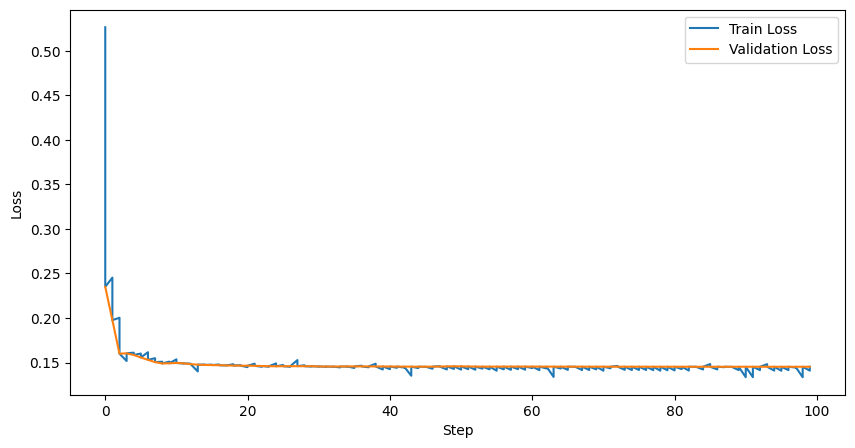

In [10]:
# Load saved training status with tbparse.SummaryReader
reader = SummaryReader(run_dir)

# plot training and validation loss
plt.figure(figsize=(10, 5))
train_loss = reader.scalars[reader.scalars["tag"] == "Loss/train"]
validation_loss = reader.scalars[reader.scalars["tag"] == "Loss/validation"]
plt.plot(train_loss["step"], train_loss["value"], label="Train Loss")
plt.plot(validation_loss["step"], validation_loss["value"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()

In [11]:
# inference on test data, verbose is True
batch_size = 20
predictions = predict_monthly_var(
    model=f"{run_dir}/best_model.pth", dataset=test_dataset, batch_size=batch_size, save_predictions=True, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

Processed batch 1/2, with loss: 0.1680
Processed batch 2/2, with loss: 0.1741
Average loss over all batches: 0.1710
Predictions saved to './runs_hourly_watervapor'


In [12]:
# inference on whole dataset
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])

dataset = STDataset(
    input_da=hourly_subset[var_name],
    monthly_da=monthly_subset_res[var_name],
    land_mask=lsm_subset["lsm"],
    patch_size=(1, *spatial_patch_size),  # based on the patch_size in model
    sh_embed_dim=96,
    sh_order_L = 10,
    is_hourly=True,    
)
print(len(dataset))

Patch grid (m x i x j): 2 x 2 x 5 = 20 patches
Overlap: 0 pixels (height), 0 pixels (width)
20


In [13]:
batch_size = 200
predictions_res = predict_monthly_var(
    model=f"{run_dir}/best_model.pth", dataset=dataset, batch_size=batch_size, verbose=False, save_predictions=True, device=device, run_dir=run_dir, dataloader_num_workers=dataloader_num_workers,
)

In [14]:
# add to monthly average
predictions = hourly_subset_averaged[var_name] + predictions_res["predictions"]

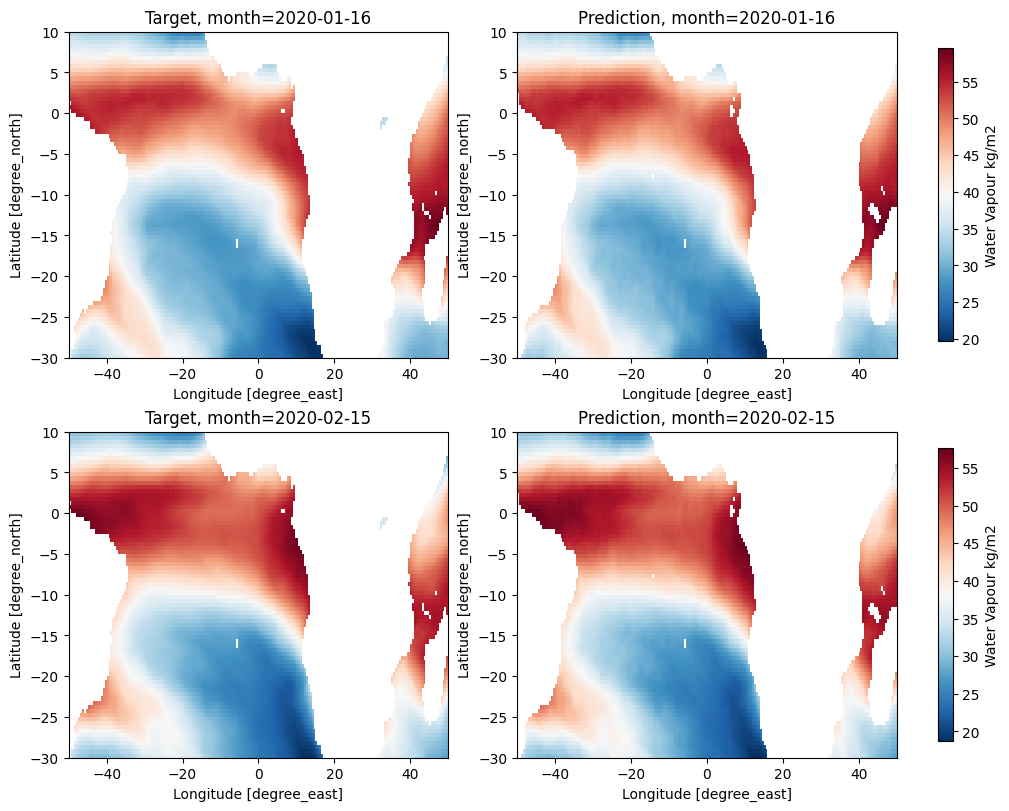

In [21]:
ocean = ~lsm_subset["lsm"].values
masked_target = monthly_subset[var_name].where(ocean)
masked_pred = predictions.where(ocean)
plot_results(masked_target, masked_pred, label="Water Vapour kg/m2", title=("Target", "Prediction"))

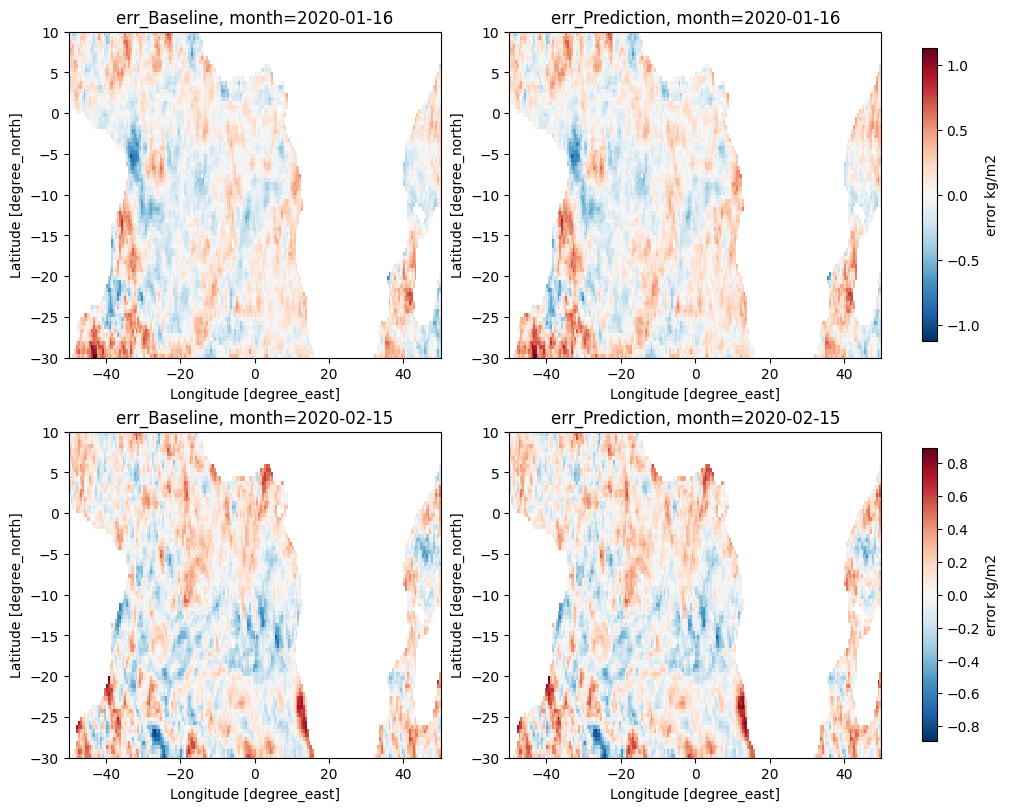

In [23]:
err_baseline = (monthly_subset[var_name] - hourly_subset_averaged[var_name])  # M - mean(D)
err_predictions = (monthly_subset[var_name] - predictions)  # M - M_hat

ocean = ~lsm_subset["lsm"].values
masked_err_baseline = err_baseline.where(ocean) 
masked_err_predictions = err_predictions.where(ocean) 

plot_results(masked_err_baseline, masked_err_predictions, label="error kg/m2", title=("err_Baseline", "err_Prediction"), error=True)

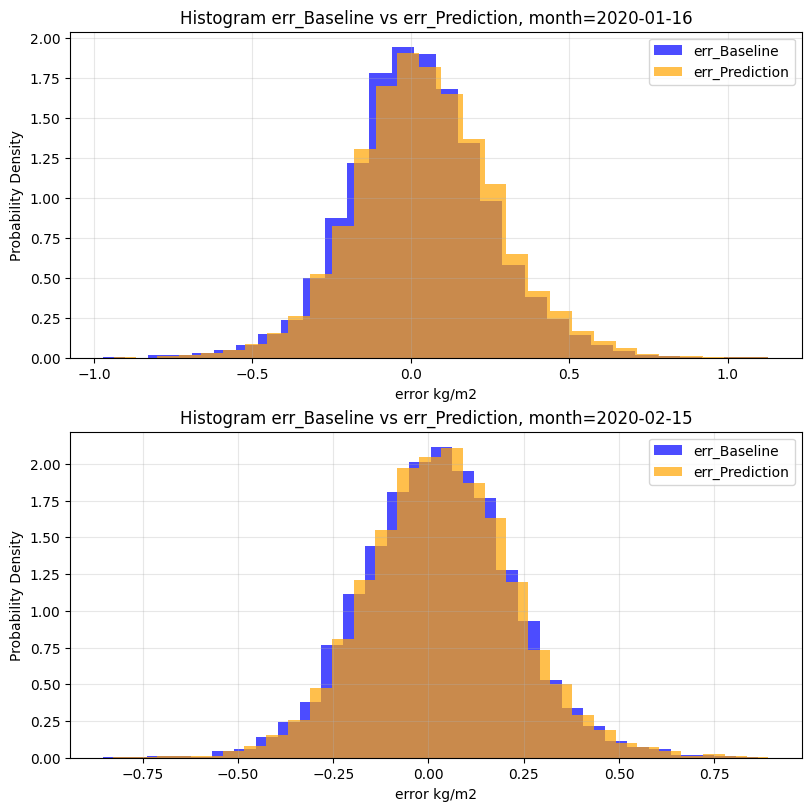

In [24]:
plot_histograms(masked_err_baseline, masked_err_predictions, label="error kg/m2", legend_labels=("err_Baseline", "err_Prediction"))